# Fragmentation (FRED)

SigmaDock represents ligands as **fragment ensembles**: the molecule is split at torsional bonds into rigid fragments. This notebook introduces the **FRED** (Fragment Ensemble Docking) pipeline used in the codebase.

**You will:**
- Fragment a molecule using `sigmadock.chem.fragmentation`
- Compare selection strategies: `random`, `smallest`, `largest`
- Visualize fragments (grid and highlighted on the molecule)
- Align and view multiple conformers with `sigmadock.chem.conformer_viz`
- Optionally view 3D fragments with py3Dmol

In [1]:
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import AllChem
import copy

from sigmadock.chem.fragmentation import (
    fragment_molecule,
    get_fragments_as_mols,
    visualize_fragments,
    visualize_fragments_on_molecule,
)
from sigmadock.chem.pyviz import view_mol

## Load a molecule

Use a SMILES string (no data directory required). For 3D viewing we add a simple conformer.

In [2]:
smiles = "CC(C)Cc1ccc(cc1)C(C)C(=O)O"  # Ibuprofen-like
mol = Chem.MolFromSmiles(smiles)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol, randomSeed=42)
AllChem.MMFFOptimizeMolecule(mol)
print(Chem.MolToSmiles(Chem.RemoveHs(mol)))
view_mol(mol, style="stick").show()

CC(C)Cc1ccc(C(C)C(=O)O)cc1


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Fragment with different strategies

`fragment_molecule` chooses which torsional bonds to cut:
- **random**: sample one minimal cut set (recommended for training)
- **smallest**: minimal cuts that favor merging small fragments (good for inference)
- **largest**: minimal cuts that yield larger fragments
- **random_all**: sample from all valid cut sets (not only minimal)

Max: 5 fragments
FR3D Random: 4 fragments


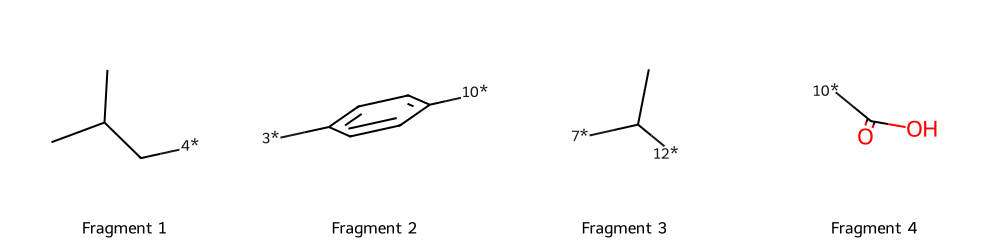

In [3]:
# Remove Hs
mol = Chem.RemoveHs(mol)

frag_mol_max = fragment_molecule(mol, selection="max")
frag_mol_smallest = fragment_molecule(mol, selection="random")

frags_max = get_fragments_as_mols(frag_mol_max, asMols=True)
frags_smallest = get_fragments_as_mols(frag_mol_smallest, asMols=True)

print("Max:", len(frags_max), "fragments")
print("FR3D Random:", len(frags_smallest), "fragments")
display(visualize_fragments(frag_mol_smallest, mols_per_row=4))

### 3D

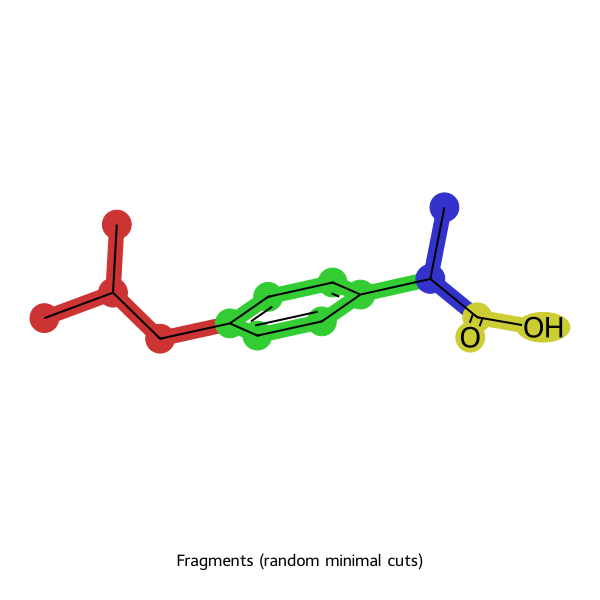

In [4]:
display(visualize_fragments_on_molecule(mol, frags_smallest, legend="Fragments (random minimal cuts)"))

### 2D

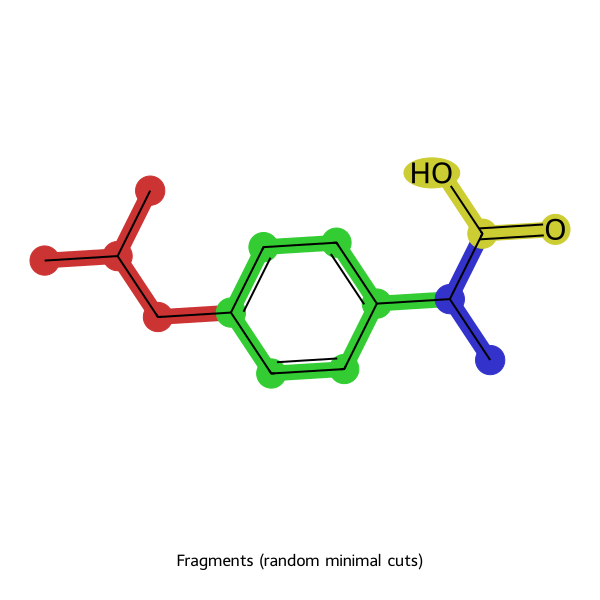

In [5]:
mol_ = copy.deepcopy(mol)
mol_.RemoveAllConformers()
display(visualize_fragments_on_molecule(mol_, frags_smallest, legend="Fragments (random minimal cuts)"))
# NOTE: The edges connecting the green benzene ring to the red fragment (di-methly) are overconstrained and therefore not present in computational graph!

## 3D view of fragmented molecule

The fragmented molecule keeps the same 3D coordinates; dummy atoms mark the cut bonds. View with py3Dmol.

In [6]:
view_mol(frag_mol_smallest, style="stick").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Valid fragmentations (analysis)

We can enumerate all **valid** fragmentation patterns: cut sets at torsional bonds such that every resulting fragment with more than 3 atoms has no torsional bonds left. This is the same logic used by `fragment_molecule` to ensure chemically sensible rigid fragments.

Torsional bonds (indices): [2, 3, 9, 11]
Number of valid fragmentation patterns: 3
Valid cut sets (bond indices): [(2, 9, 11), (3, 9, 11), (2, 3, 9, 11)] 

Valid fragmentation patterns (each as sorted list of cut indices):
[2, 9, 11]
[3, 9, 11]
[2, 3, 9, 11]


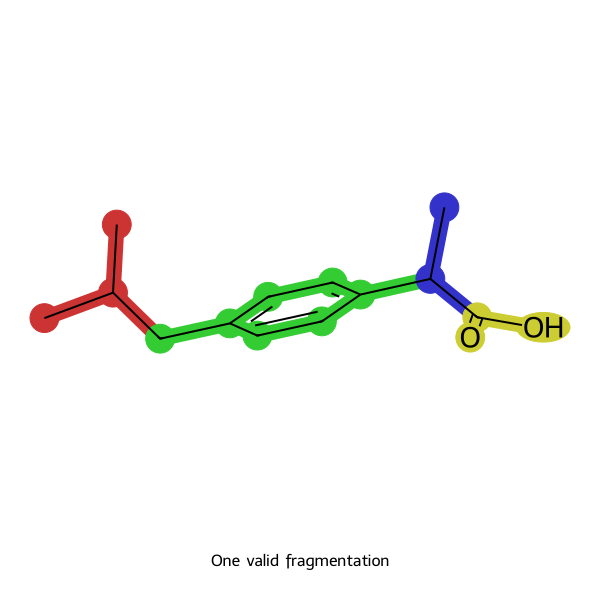

In [7]:
from sigmadock.chem.fragmentation import (
    detect_torsional_bonds,
    enumerate_valid_fragmentations,
    fragment_on_bonds_with_mapping,
    get_fragments_as_mols,
    visualize_fragments_on_molecule,
)

torsions = sorted(detect_torsional_bonds(mol, ignore_conjugated=False))
valid_cuts = enumerate_valid_fragmentations(mol, ignore_conjugated=False)
# Each element is a frozenset of bond indices (cut set)
valid_sorted = sorted(valid_cuts, key=lambda s: (len(s), sorted(s)))
print(f"Torsional bonds (indices): {torsions}")
print(f"Number of valid fragmentation patterns: {len(valid_sorted)}")
print("Valid cut sets (bond indices):", [tuple(sorted(s)) for s in valid_sorted[:10]], "..." if len(valid_sorted) > 10 else "")
print("\nValid fragmentation patterns (each as sorted list of cut indices):")
for s in valid_sorted:
    print(list(sorted(s)))

# Visualize one valid fragmentation (e.g. smallest non-empty cut set)
if valid_sorted:
    cut_list = list(valid_sorted[0])
    frag_mol_valid = fragment_on_bonds_with_mapping(mol, cut_list)
    frags_valid = get_fragments_as_mols(frag_mol_valid)
    display(visualize_fragments_on_molecule(mol, frags_valid, legend="One valid fragmentation"))

In [8]:
from sigmadock.chem.conformer_viz import view_aligned_conformers

# Generate several conformers (e.g. with different random seeds)
mol_multi = Chem.MolFromSmiles(smiles)
# mol_multi = Chem.AddHs(mol_multi) # NOTE: Hiding to reduce clutter, also not needed for FR3D
AllChem.EmbedMultipleConfs(mol_multi, numConfs=16, randomSeed=123)
cids = [c.GetId() for c in mol_multi.GetConformers()]
# Align to an arbitrary conformer and view (RMSDs attached to view as view._rmsds)
view_aligned = view_aligned_conformers(mol_multi, conf_ids=cids, ref_conf_id=cids[1], clone_and_align=True)
view_aligned.show()
if hasattr(view_aligned, "_rmsds"):
    print("RMSDs to ref (Å):", view_aligned._rmsds.round(3).tolist())

[09:00:22] Molecule does not have explicit Hs. Consider calling AddHs()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

RMSDs to ref (Å): [1.6, 0.0, 1.425, 1.268, 1.764, 1.559, 0.959, 1.576, 1.554, 1.288, 1.655, 0.967, 1.551, 1.342, 1.565, 1.393]


## Summary

- **FRED** in SigmaDock: minimal cut sets at torsional bonds → rigid fragments.
- Use `fragment_molecule(mol, selection="random")` for training; `selection="smallest"` for inference.
- `get_fragments_as_mols`, `visualize_fragments`, and `visualize_fragments_on_molecule` help inspect and debug fragmentation.